1. **Creating a Custom Dataset for your files**

    A custom Dataset class must implement three functions: __init__, __len__, and __getitem__. Take a look at this implementation; the SatelliteImageClassification images are stored in a directory img_dir, and their labels are stored separately in a CSV file annotations_file.

    ```
    __init__
    ```
    The \__init__ function is run once when instantiating the Dataset object. We initialize the annotations file, and both transforms


    ```
    __len__
    ```
    The \__len__ function returns the number of samples in our dataset.


    ```
    __getitem__
    ```
    The \__getitem__ function loads and returns a sample from the dataset at the given index idx. Based on the index, it identifies the image’s location on disk, converts that to a tensor using read_image, retrieves the corresponding label from the csv data in self.img_labels, calls the transform functions on them (if applicable), and returns the tensor image and corresponding label in a tuple.

In [1]:
from torch.utils.data import Dataset
from PIL import Image

import pandas as pd
import numpy as np
import os

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.dataframe = pd.read_csv(annotations_file)
        self.classes = list(self.dataframe.columns[2:])
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.dataframe.index)

    def __getitem__(self, idx):
        img_name = self.dataframe.loc[idx, 'Id']
        img_path = os.path.join(self.img_dir, img_name + '.jpg')
        label = self.dataframe.loc[idx, self.classes]

        # Load image
        image = Image.open(img_path).convert('RGB')

        # Convert to numpy
        label = np.array(label, dtype=np.float32)

        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

    def get_class_name(self):
        return self.classes

    - Preparing your data for training with DataLoaders

In [2]:
import torchvision.transforms.v2 as transforms
from torch.utils.data import DataLoader
import torch

transform = transforms.Compose([
    transforms.Resize((425, 300)),
    transforms.ToImage(),  # Convert to image format
    transforms.ConvertImageDtype(torch.float32),  # Convert image dtype
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])


testset = CustomImageDataset(annotations_file='./Multi_Label_dataset/test_data.csv', img_dir='./Multi_Label_dataset', transform=transform)
testloader = DataLoader(testset, batch_size=4, shuffle=True)

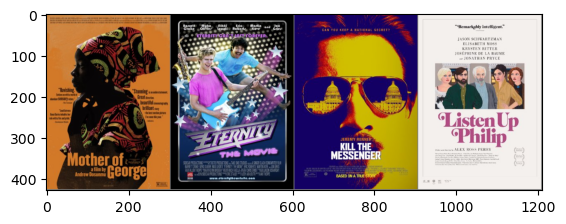

class: [['Drama'], ['Comedy', 'Music', 'Musical'], ['Biography', 'Crime', 'Drama'], ['Comedy', 'Drama']]


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(testloader)
images, labels = next(dataiter)

# show images
classes = np.array(testset.classes)
imshow(torchvision.utils.make_grid(images))

# print labels
print(f'class: {[classes[np.where(labels[j]==1)].tolist() for j in range(4)]}')

2. Define a Convolutional Neural Network

In [4]:
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn

# New weights with accuracy 80.858%
classes = testset.get_class_name()
model = resnet50()
model.fc = nn.Linear(2048, len(classes))
model.load_state_dict(torch.load('./multi_classification_model.pt'))


<All keys matched successfully>

In [5]:
from sklearn.metrics import accuracy_score
from torch.nn.functional import sigmoid

# Check if GPU (cuda) is available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Move our model to device (GPU or CPU)
model.to(device)
model.eval()

correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for inputs, labels in testloader:
        images, labels = inputs.to(device), labels.to(device)
        # calculate outputs by running images through the network
        outputs = model(images)

        # Normalize range
        outputs = sigmoid(outputs)

        # Convert to zero and one base on threshold
        outputs = (outputs > 0.2) * 1

        correct += accuracy_score(labels.cpu(), outputs.cpu())
        total += 1

print(f'Accuracy of the network on the test images: {100 * correct // total:.02f} %')


Accuracy of the network on the test images: 4.00 %
